In [ ]:
# import libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# mount google drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# load the data

health_df = pd.read_csv("/content/drive/MyDrive/My Health Blogs/Hypertension_Cardiology_Center_Dataset.csv")
health_df.head()

,Patient_ID,Age,Gender,Diabetes_Mellitus,Chronic_Kidney_Disease,Dyslipidemia,Obesity,Baseline_Systolic_BP,Baseline_Diastolic_BP,Antihypertensive_Class,Medication_Adherence,Followup_Systolic_BP,Followup_Diastolic_BP,BP_Controlled_After_3_Months,Number_of_Visits,Registration_Date
0,HTN0001,70,Male,Yes,No,Yes,Yes,148,113,ACE Inhibitor,Poor,142,110,No,1,2024-01-16
1,HTN0002,35,Male,Yes,Yes,Yes,No,154,104,Beta Blocker,Moderate,144,98,No,3,2024-05-22
2,HTN0003,39,Male,No,Yes,Yes,No,146,101,Calcium Channel Blocker,Poor,139,97,No,5,2024-03-04
3,HTN0004,54,Male,No,No,Yes,Yes,142,111,ARB,Moderate,131,105,No,4,2024-05-22
4,HTN0005,59,Female,Yes,No,No,Yes,182,98,Combination Therapy,Poor,166,89,No,5,2024-05-05


In [ ]:
# santity audit

health_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Patient_ID                    350 non-null    object
 1   Age                           350 non-null    int64 
 2   Gender                        350 non-null    object
 3   Diabetes_Mellitus             350 non-null    object
 4   Chronic_Kidney_Disease        350 non-null    object
 5   Dyslipidemia                  350 non-null    object
 6   Obesity                       350 non-null    object
 7   Baseline_Systolic_BP          350 non-null    int64 
 8   Baseline_Diastolic_BP         350 non-null    int64 
 9   Antihypertensive_Class        350 non-null    object
 10  Medication_Adherence          350 non-null    object
 11  Followup_Systolic_BP          350 non-null    int64 
 12  Followup_Diastolic_BP         350 non-null    int64 
 13  BP_Controlled_After_

In [ ]:
# null check

health_df.isnull().sum()

,0
Patient_ID,0
Age,0
Gender,0
Diabetes_Mellitus,0
Chronic_Kidney_Disease,0
Dyslipidemia,0
Obesity,0
Baseline_Systolic_BP,0
Baseline_Diastolic_BP,0
Antihypertensive_Class,0


In [ ]:
# summary statistics

health_df.describe()

,Age,Baseline_Systolic_BP,Baseline_Diastolic_BP,Followup_Systolic_BP,Followup_Diastolic_BP,Number_of_Visits
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,57.431429,165.957143,105.314286,151.465714,97.005714,3.371429
std,16.015381,14.529129,8.665617,16.496165,9.904413,1.684000
min,30.000000,140.000000,90.000000,110.000000,72.000000,1.000000
25%,43.250000,155.000000,98.000000,141.000000,89.000000,2.000000
50%,57.500000,167.000000,106.000000,152.500000,97.000000,3.000000
75%,71.750000,179.000000,112.000000,163.000000,104.000000,5.000000
max,85.000000,190.000000,120.000000,186.000000,120.000000,6.000000


In [ ]:
# control count measure

control_count = health_df['BP_Controlled_After_3_Months'].value_counts(normalize=True) * 100
control_count

,proportion
BP_Controlled_After_3_Months,
No,90.571429
Yes,9.428571


In [ ]:
# create new columns for the drop in BP

health_df['SBP_Drop'] = health_df['Baseline_Systolic_BP'] - health_df['Followup_Systolic_BP']
health_df['DBP_Drop'] = health_df['Baseline_Diastolic_BP'] - health_df['Followup_Diastolic_BP']
health_df.head()

,Patient_ID,Age,Gender,Diabetes_Mellitus,Chronic_Kidney_Disease,Dyslipidemia,Obesity,Baseline_Systolic_BP,Baseline_Diastolic_BP,Antihypertensive_Class,Medication_Adherence,Followup_Systolic_BP,Followup_Diastolic_BP,BP_Controlled_After_3_Months,Number_of_Visits,Registration_Date,SBP_Drop,DBP_Drop
0,HTN0001,70,Male,Yes,No,Yes,Yes,148,113,ACE Inhibitor,Poor,142,110,No,1,2024-01-16,6,3
1,HTN0002,35,Male,Yes,Yes,Yes,No,154,104,Beta Blocker,Moderate,144,98,No,3,2024-05-22,10,6
2,HTN0003,39,Male,No,Yes,Yes,No,146,101,Calcium Channel Blocker,Poor,139,97,No,5,2024-03-04,7,4
3,HTN0004,54,Male,No,No,Yes,Yes,142,111,ARB,Moderate,131,105,No,4,2024-05-22,11,6
4,HTN0005,59,Female,Yes,No,No,Yes,182,98,Combination Therapy,Poor,166,89,No,5,2024-05-05,16,9


In [ ]:
health_df['SBP_Drop'].mean()

np.float64(14.491428571428571)

In [ ]:
health_df['DBP_Drop'].mean()

np.float64(8.308571428571428)

In [ ]:
# control analysis

c_analysis = health_df.groupby('BP_Controlled_After_3_Months')[['Number_of_Visits', 'SBP_Drop', 'Age']].mean()
c_analysis

,Number_of_Visits,SBP_Drop,Age
BP_Controlled_After_3_Months,,,
No,3.350158,13.681388,57.577287
Yes,3.575758,22.272727,56.030303


In [ ]:
# adherence category split

adherence_impact = pd.crosstab(health_df['Medication_Adherence'], health_df['BP_Controlled_After_3_Months'], normalize='index') * 100
adherence_impact

BP_Controlled_After_3_Months,No,Yes
Medication_Adherence,,
Good,84.761905,15.238095
Moderate,88.636364,11.363636
Poor,98.230088,1.769912


In [ ]:
# diabetes impact

diabetes_impact = pd.crosstab(health_df['Diabetes_Mellitus'], health_df['BP_Controlled_After_3_Months'], normalize='index') * 100
diabetes_impact

BP_Controlled_After_3_Months,No,Yes
Diabetes_Mellitus,,
No,91.071429,8.928571
Yes,90.109890,9.890110


In [ ]:
# obesity impact

obesity_impact = pd.crosstab(health_df['Obesity'], health_df['BP_Controlled_After_3_Months'], normalize='index') * 100
obesity_impact

BP_Controlled_After_3_Months,No,Yes
Obesity,,
No,90.243902,9.756098
Yes,90.860215,9.139785


In [ ]:
# chronic kidney disease impact

CKD_impact = pd.crosstab(health_df['Chronic_Kidney_Disease'], health_df['BP_Controlled_After_3_Months'], normalize='index') * 100
CKD_impact

BP_Controlled_After_3_Months,No,Yes
Chronic_Kidney_Disease,,
No,88.095238,11.904762
Yes,92.857143,7.142857


In [ ]:
# dyslipidemia impact

dyslipidemia_impact = pd.crosstab(health_df['Dyslipidemia'], health_df['BP_Controlled_After_3_Months'], normalize='index') * 100
dyslipidemia_impact

BP_Controlled_After_3_Months,No,Yes
Dyslipidemia,,
No,91.443850,8.556150
Yes,89.570552,10.429448


In [ ]:
# success rate (Yes) for each drug, separated by Obesity status

obesity_analysis = health_df.pivot_table(index='Antihypertensive_Class',
                                      columns='Obesity',
                                      values='BP_Controlled_After_3_Months',
                                      aggfunc=lambda x: (x == 'Yes').mean() * 100)
obesity_analysis

Obesity,No,Yes
Antihypertensive_Class,,
ACE Inhibitor,0.000000,0.000000
ARB,3.030303,8.571429
Beta Blocker,14.705882,3.703704
Calcium Channel Blocker,3.225806,7.407407
Combination Therapy,26.315789,18.421053
Thiazide Diuretic,15.384615,11.428571


In [ ]:
# success rate (Yes) for each drug, separated by Diabetes_Mellitus status

diabetes_analysis = health_df.pivot_table(index='Antihypertensive_Class',
                                      columns='Diabetes_Mellitus',
                                      values='BP_Controlled_After_3_Months',
                                      aggfunc=lambda x: (x == 'Yes').mean() * 100)
diabetes_analysis

Diabetes_Mellitus,No,Yes
Antihypertensive_Class,,
ACE Inhibitor,0.000000,0.000000
ARB,5.555556,6.250000
Beta Blocker,12.500000,8.108108
Calcium Channel Blocker,6.250000,3.846154
Combination Therapy,16.000000,25.000000
Thiazide Diuretic,16.000000,11.111111


In [ ]:
# success rate (Yes) for each drug, separated by Dyslipidemia status

dyslipidemia_analysis = health_df.pivot_table(index='Antihypertensive_Class',
                                      columns='Dyslipidemia',
                                      values='BP_Controlled_After_3_Months',
                                      aggfunc=lambda x: (x == 'Yes').mean() * 100)
dyslipidemia_analysis

Dyslipidemia,No,Yes
Antihypertensive_Class,,
ACE Inhibitor,0.000000,0.000000
ARB,5.405405,6.451613
Beta Blocker,9.375000,10.344828
Calcium Channel Blocker,7.407407,3.225806
Combination Therapy,16.666667,25.925926
Thiazide Diuretic,10.810811,16.666667


In [ ]:
# success rate (Yes) for each drug, separated by CKD status

drug_analysis = health_df.pivot_table(index='Antihypertensive_Class',
                                      columns='Chronic_Kidney_Disease',
                                      values='BP_Controlled_After_3_Months',
                                      aggfunc=lambda x: (x == 'Yes').mean() * 100)
drug_analysis

Chronic_Kidney_Disease,No,Yes
Antihypertensive_Class,,
ACE Inhibitor,0.000000,0.000000
ARB,8.108108,3.225806
Beta Blocker,15.384615,5.714286
Calcium Channel Blocker,6.896552,3.448276
Combination Therapy,29.032258,11.538462
Thiazide Diuretic,7.407407,17.647059


In [ ]:
# success rate (Yes) for each drugs, separated by medication adherence status

adherence_analysis = health_df.pivot_table(index='Antihypertensive_Class',
                                           columns='Medication_Adherence',
                                           values='BP_Controlled_After_3_Months',
                                           aggfunc=lambda x: (x == 'Yes').mean() * 100)
adherence_analysis

Medication_Adherence,Good,Moderate,Poor
Antihypertensive_Class,,,
ACE Inhibitor,0.000000,0.000000,0.000000
ARB,23.076923,3.703704,0.000000
Beta Blocker,15.789474,14.285714,0.000000
Calcium Channel Blocker,5.882353,4.545455,5.263158
Combination Therapy,25.000000,28.000000,6.250000
Thiazide Diuretic,25.000000,12.500000,0.000000


In [ ]:
# confirming BP control in ACE Inhibitor

print(health_df.groupby('Antihypertensive_Class')['BP_Controlled_After_3_Months'].value_counts())

Antihypertensive_Class   BP_Controlled_After_3_Months
ACE Inhibitor            No                              45
ARB                      No                              64
                         Yes                              4
Beta Blocker             No                              55
                         Yes                              6
Calcium Channel Blocker  No                              55
                         Yes                              3
Combination Therapy      No                              45
                         Yes                             12
Thiazide Diuretic        No                              53
                         Yes                              8
Name: count, dtype: int64


In [ ]:
# calculate the success rate per drug class

success_rates = health_df.groupby('Antihypertensive_Class')['BP_Controlled_After_3_Months'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
success_rates.columns = ['Drug Class', 'Success Rate (%)']
success_rates = success_rates.sort_values(by='Success Rate (%)', ascending=False)
success_rates

,Drug Class,Success Rate (%)
4,Combination Therapy,21.052632
5,Thiazide Diuretic,13.114754
2,Beta Blocker,9.836066
1,ARB,5.882353
3,Calcium Channel Blocker,5.172414
0,ACE Inhibitor,0.000000


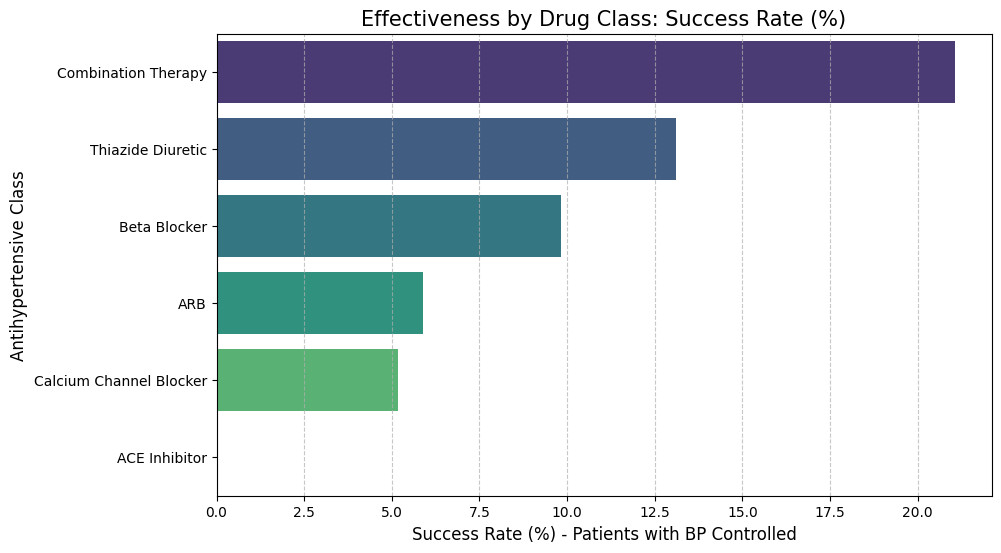

In [ ]:
# visualize drug class and success rate

plt.figure(figsize=(10, 6))
sns.barplot(x='Success Rate (%)', y='Drug Class', data=success_rates, hue='Drug Class', palette='viridis', legend=False)
plt.title('Effectiveness by Drug Class: Success Rate (%)', fontsize=15)
plt.xlabel('Success Rate (%) - Patients with BP Controlled', fontsize=12)
plt.ylabel('Antihypertensive Class', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

In [ ]:
# comparing the starting BP of those who succeeded vs those who failed

severity_anlysis = health_df.groupby('BP_Controlled_After_3_Months')['Baseline_Systolic_BP'].describe()
severity_anlysis

,count,mean,std,min,25%,50%,75%,max
BP_Controlled_After_3_Months,,,,,,,,
No,317.0,167.839117,13.831581,140.0,157.0,169.0,180.0,190.0
Yes,33.0,147.878788,6.397058,140.0,143.0,147.0,152.0,165.0


In [ ]:
# create a Risk Score starting at 0

health_df['Risk_Score'] = 0

# add 1 point for high baseline BP using the mean (165)

health_df.loc[health_df['Baseline_Systolic_BP'] > 165, 'Risk_Score'] += 1

# add 1 point for Chronic Kidney Disease

health_df.loc[health_df['Chronic_Kidney_Disease'] == 'Yes', 'Risk_Score'] += 1

# add 1 point for Poor Adherence

health_df.loc[health_df['Medication_Adherence'] == 'Poor', 'Risk_Score'] += 1

health_df.head()

,Patient_ID,Age,Gender,Diabetes_Mellitus,Chronic_Kidney_Disease,Dyslipidemia,Obesity,Baseline_Systolic_BP,Baseline_Diastolic_BP,Antihypertensive_Class,Medication_Adherence,Followup_Systolic_BP,Followup_Diastolic_BP,BP_Controlled_After_3_Months,Number_of_Visits,Registration_Date,SBP_Drop,DBP_Drop,Risk_Score
0,HTN0001,70,Male,Yes,No,Yes,Yes,148,113,ACE Inhibitor,Poor,142,110,No,1,2024-01-16,6,3,1
1,HTN0002,35,Male,Yes,Yes,Yes,No,154,104,Beta Blocker,Moderate,144,98,No,3,2024-05-22,10,6,1
2,HTN0003,39,Male,No,Yes,Yes,No,146,101,Calcium Channel Blocker,Poor,139,97,No,5,2024-03-04,7,4,2
3,HTN0004,54,Male,No,No,Yes,Yes,142,111,ARB,Moderate,131,105,No,4,2024-05-22,11,6,0
4,HTN0005,59,Female,Yes,No,No,Yes,182,98,Combination Therapy,Poor,166,89,No,5,2024-05-05,16,9,2


In [ ]:
# risk prediction validation

risk_validation = pd.crosstab(health_df['Risk_Score'], health_df['BP_Controlled_After_3_Months'], normalize='index') * 100
risk_validation

BP_Controlled_After_3_Months,No,Yes
Risk_Score,,
0,63.461538,36.538462
1,90.972222,9.027778
2,99.193548,0.806452
3,100.000000,0.000000


**FROM INSIGHTS TO PREDICTION (MACHINE LEARNING)**

In [ ]:
# create ML safe copy

ml_df = health_df.copy()
ml_df.head()

,Patient_ID,Age,Gender,Diabetes_Mellitus,Chronic_Kidney_Disease,Dyslipidemia,Obesity,Baseline_Systolic_BP,Baseline_Diastolic_BP,Antihypertensive_Class,Medication_Adherence,Followup_Systolic_BP,Followup_Diastolic_BP,BP_Controlled_After_3_Months,Number_of_Visits,Registration_Date,SBP_Drop,DBP_Drop,Risk_Score
0,HTN0001,70,Male,Yes,No,Yes,Yes,148,113,ACE Inhibitor,Poor,142,110,No,1,2024-01-16,6,3,1
1,HTN0002,35,Male,Yes,Yes,Yes,No,154,104,Beta Blocker,Moderate,144,98,No,3,2024-05-22,10,6,1
2,HTN0003,39,Male,No,Yes,Yes,No,146,101,Calcium Channel Blocker,Poor,139,97,No,5,2024-03-04,7,4,2
3,HTN0004,54,Male,No,No,Yes,Yes,142,111,ARB,Moderate,131,105,No,4,2024-05-22,11,6,0
4,HTN0005,59,Female,Yes,No,No,Yes,182,98,Combination Therapy,Poor,166,89,No,5,2024-05-05,16,9,2


In [ ]:
# encode comorbidities

binary_cols = ['Diabetes_Mellitus', 'Chronic_Kidney_Disease', 'Dyslipidemia', 'Obesity']
for col in binary_cols:
  ml_df[col] = ml_df[col].map({'Yes': 1, 'No': 0})
ml_df.head()

,Patient_ID,Age,Gender,Diabetes_Mellitus,Chronic_Kidney_Disease,Dyslipidemia,Obesity,Baseline_Systolic_BP,Baseline_Diastolic_BP,Antihypertensive_Class,Medication_Adherence,Followup_Systolic_BP,Followup_Diastolic_BP,BP_Controlled_After_3_Months,Number_of_Visits,Registration_Date,SBP_Drop,DBP_Drop,Risk_Score
0,HTN0001,70,Male,1,0,1,1,148,113,ACE Inhibitor,Poor,142,110,No,1,2024-01-16,6,3,1
1,HTN0002,35,Male,1,1,1,0,154,104,Beta Blocker,Moderate,144,98,No,3,2024-05-22,10,6,1
2,HTN0003,39,Male,0,1,1,0,146,101,Calcium Channel Blocker,Poor,139,97,No,5,2024-03-04,7,4,2
3,HTN0004,54,Male,0,0,1,1,142,111,ARB,Moderate,131,105,No,4,2024-05-22,11,6,0
4,HTN0005,59,Female,1,0,0,1,182,98,Combination Therapy,Poor,166,89,No,5,2024-05-05,16,9,2


In [ ]:
# encoding model target (BP_Controlled_After_3_Months)

ml_df['Target'] = ml_df['BP_Controlled_After_3_Months'].map({'Yes': 1, 'No': 0})
ml_df.head()

,Patient_ID,Age,Gender,Diabetes_Mellitus,Chronic_Kidney_Disease,Dyslipidemia,Obesity,Baseline_Systolic_BP,Baseline_Diastolic_BP,Antihypertensive_Class,Medication_Adherence,Followup_Systolic_BP,Followup_Diastolic_BP,BP_Controlled_After_3_Months,Number_of_Visits,Registration_Date,SBP_Drop,DBP_Drop,Risk_Score,Target
0,HTN0001,70,Male,1,0,1,1,148,113,ACE Inhibitor,Poor,142,110,No,1,2024-01-16,6,3,1,0
1,HTN0002,35,Male,1,1,1,0,154,104,Beta Blocker,Moderate,144,98,No,3,2024-05-22,10,6,1,0
2,HTN0003,39,Male,0,1,1,0,146,101,Calcium Channel Blocker,Poor,139,97,No,5,2024-03-04,7,4,2,0
3,HTN0004,54,Male,0,0,1,1,142,111,ARB,Moderate,131,105,No,4,2024-05-22,11,6,0,0
4,HTN0005,59,Female,1,0,0,1,182,98,Combination Therapy,Poor,166,89,No,5,2024-05-05,16,9,2,0


In [ ]:
# encode medication adherence with one-hot

ml_df = pd.get_dummies(ml_df, columns=['Medication_Adherence'], prefix='Adherence', dtype=int)
ml_df.head()

,Patient_ID,Age,Gender,Diabetes_Mellitus,Chronic_Kidney_Disease,Dyslipidemia,Obesity,Baseline_Systolic_BP,Baseline_Diastolic_BP,Antihypertensive_Class,...,BP_Controlled_After_3_Months,Number_of_Visits,Registration_Date,SBP_Drop,DBP_Drop,Risk_Score,Target,Adherence_Good,Adherence_Moderate,Adherence_Poor
0,HTN0001,70,Male,1,0,1,1,148,113,ACE Inhibitor,...,No,1,2024-01-16,6,3,1,0,0,0,1
1,HTN0002,35,Male,1,1,1,0,154,104,Beta Blocker,...,No,3,2024-05-22,10,6,1,0,0,1,0
2,HTN0003,39,Male,0,1,1,0,146,101,Calcium Channel Blocker,...,No,5,2024-03-04,7,4,2,0,0,0,1
3,HTN0004,54,Male,0,0,1,1,142,111,ARB,...,No,4,2024-05-22,11,6,0,0,0,1,0
4,HTN0005,59,Female,1,0,0,1,182,98,Combination Therapy,...,No,5,2024-05-05,16,9,2,0,0,0,1


In [ ]:
# define Features & Targets

features = ['Age', 'Baseline_Systolic_BP', 'Baseline_Diastolic_BP', 'Number_of_Visits', 'Diabetes_Mellitus', 'Chronic_Kidney_Disease', 'Dyslipidemia', 'Obesity', 'Adherence_Good', 'Adherence_Moderate', 'Adherence_Poor']

X = ml_df[features]
y = ml_df['Target']
X.head()

,Age,Baseline_Systolic_BP,Baseline_Diastolic_BP,Number_of_Visits,Diabetes_Mellitus,Chronic_Kidney_Disease,Dyslipidemia,Obesity,Adherence_Good,Adherence_Moderate,Adherence_Poor
0,70,148,113,1,1,0,1,1,0,0,1
1,35,154,104,3,1,1,1,0,0,1,0
2,39,146,101,5,0,1,1,0,0,0,1
3,54,142,111,4,0,0,1,1,0,1,0
4,59,182,98,5,1,0,0,1,0,0,1


In [ ]:
# train test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# balance training data with SMOTE

sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

# print resamples shape to confirm

X_train_resampled.shape, y_train_resampled.shape

((504, 11), (504,))

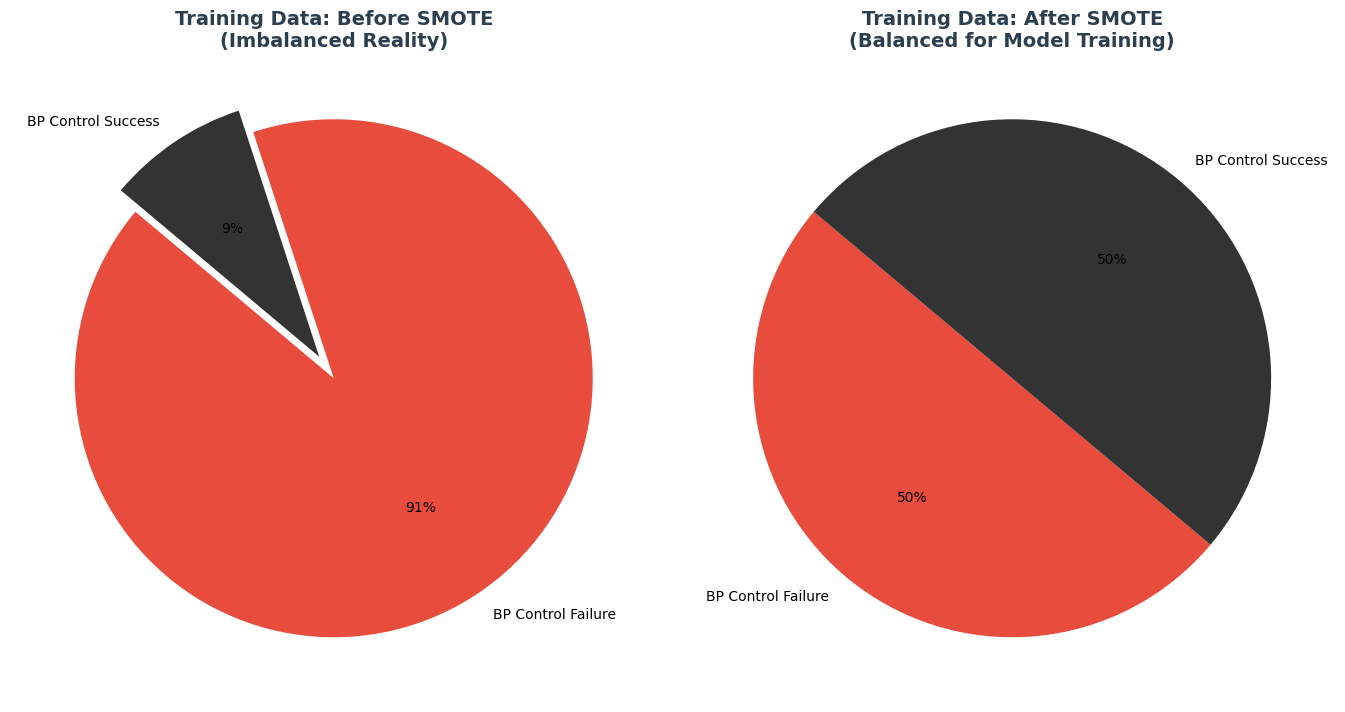

In [ ]:
# 1. Define the counts based on your original data and your SMOTE results

# Before SMOTE: 91% Failure (319) vs 9% Success (31)

before_counts = [319, 31]



# After SMOTE: The training set is now balanced

# Both classes now match the majority count

after_counts = [504, 504]



labels = ['BP Control Failure', 'BP Control Success']

colors = ['#E74C3C', '#333333'] # Clinical Red for Failure, Clinical Green for Success



# 2. Create the side-by-side comparison

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))



# Pie Chart for Original Data (X_train / y_train)

ax1.pie(before_counts, labels=labels, autopct='%1.0f%%', startangle=140, colors=colors, explode=(0, 0.1))

ax1.set_title('Training Data: Before SMOTE\n(Imbalanced Reality)', fontsize=14, fontweight='bold', color='#2C3E50')



# Pie Chart for Balanced Data (balanced_X_train / balanced_y_train)

ax2.pie(after_counts, labels=labels, autopct='%1.0f%%', startangle=140, colors=colors)

ax2.set_title('Training Data: After SMOTE\n(Balanced for Model Training)', fontsize=14, fontweight='bold', color='#2C3E50')



plt.tight_layout()

plt.show()

In [ ]:
# confirm test shape

X_test.shape, y_test.shape

((70, 11), (70,))

In [ ]:
# train model on resampled data

rfc_model = RandomForestClassifier(n_estimators=100, random_state=42)
rfc_model.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(random_state=42)

In [ ]:
# evaluate model on unbalanced test data

predictions = rfc_model.predict(X_test)
classification_report(y_test, predictions)

'              precision    recall  f1-score   support\n\n           0       0.98      0.97      0.98        65\n           1       0.67      0.80      0.73         5\n\n    accuracy                           0.96        70\n   macro avg       0.83      0.88      0.85        70\nweighted avg       0.96      0.96      0.96        70\n'

              precision    recall  f1-score   support

           0       0.98      0.97      0.98        65
           1       0.67      0.80      0.73         5

    accuracy                           0.96        70
   macro avg       0.83      0.88      0.85        70
weighted avg       0.96      0.96      0.96        70


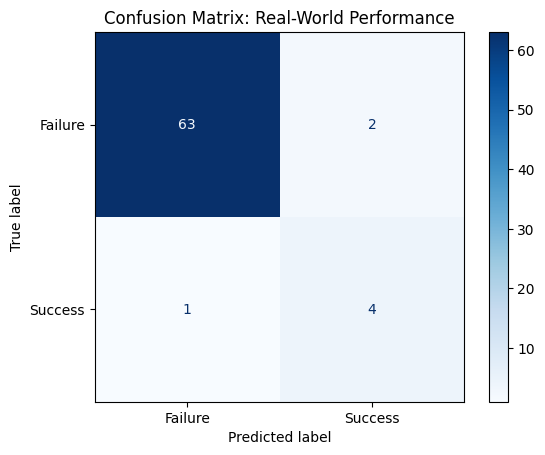

In [ ]:
# visualize confusion matrix

cm = confusion_matrix(y_test, predictions)
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Failure', 'Success'])
disp_cm.plot(cmap='Blues')
plt.title('Confusion Matrix: Real-World Performance')

plt.show()

In [ ]:
# get the importance

importances = rfc_model.feature_importances_
feature_names = features

# create DF

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
feature_importance_df.head()

,Feature,Importance
1,Baseline_Systolic_BP,0.386201
2,Baseline_Diastolic_BP,0.279140
10,Adherence_Poor,0.121967
5,Chronic_Kidney_Disease,0.057149
0,Age,0.053093


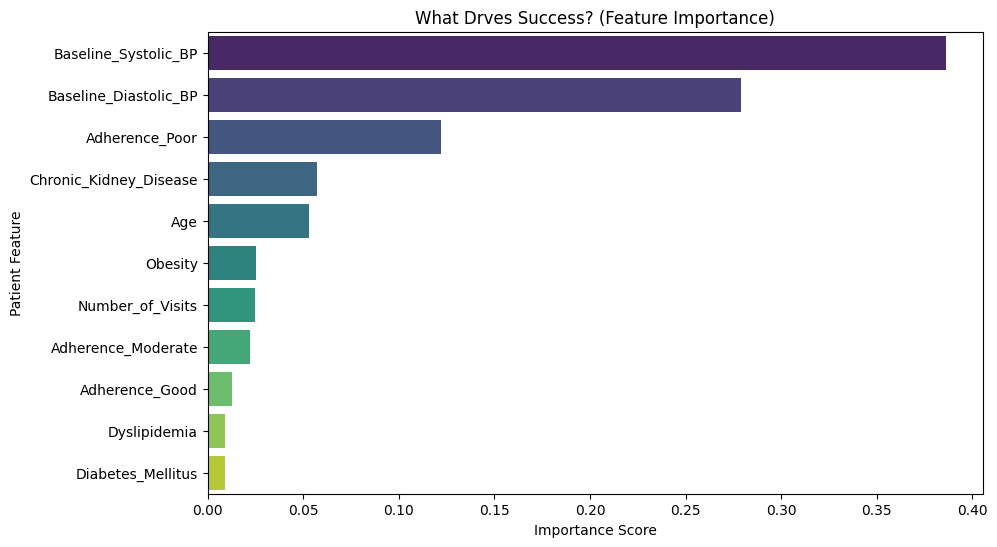

In [ ]:
# plot feature importance

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, hue='Feature', palette='viridis')
plt.title('What Drives Success? (Feature Importance)')
plt.xlabel('Importance Score')
plt.ylabel('Patient Feature')

plt.show()

In [ ]:
# create DF from the test feature

report_df = X_test.copy()

# add true reality and the model's prediction

report_df['Actual_Outcome'] = y_test.map({1: 'Success', 0: 'Failure'})
report_df['Model_Prediction'] = predictions
report_df['Model_Prediction'] = report_df['Model_Prediction'].map({1: 'Success', 0: 'Failure'})

# add a status column to check model accuracy

report_df['M_Result'] = report_df.apply(
    lambda x: '✅ Correct' if x['Actual_Outcome'] == x['Model_Prediction'] else '❌ Error', axis=1
)
report_df.head()

,Age,Baseline_Systolic_BP,Baseline_Diastolic_BP,Number_of_Visits,Diabetes_Mellitus,Chronic_Kidney_Disease,Dyslipidemia,Obesity,Adherence_Good,Adherence_Moderate,Adherence_Poor,Actual_Outcome,Model_Prediction,M_Result
157,82,144,119,2,1,1,0,0,1,0,0,Failure,Failure,✅ Correct
341,46,166,120,3,0,1,1,0,0,0,1,Failure,Failure,✅ Correct
315,72,161,101,5,0,1,1,0,0,0,1,Failure,Failure,✅ Correct
234,39,183,99,5,1,0,0,1,1,0,0,Failure,Failure,✅ Correct
155,71,159,95,3,1,1,1,0,0,0,1,Failure,Failure,✅ Correct


In [ ]:
final_report = report_df.sort_values(by='Actual_Outcome', ascending=False)
final_report[['Age', 'Baseline_Systolic_BP', 'Adherence_Poor', 'Actual_Outcome', 'Model_Prediction', 'M_Result']].head(7)

,Age,Baseline_Systolic_BP,Adherence_Poor,Actual_Outcome,Model_Prediction,M_Result
63,50,143,0,Success,Success,✅ Correct
309,39,144,0,Success,Success,✅ Correct
119,64,148,0,Success,Success,✅ Correct
173,46,150,1,Success,Failure,❌ Error
278,61,154,0,Success,Success,✅ Correct
152,51,157,0,Failure,Success,❌ Error
338,52,145,1,Failure,Failure,✅ Correct
